# METODE B: Full ViT Fine-tuning
## ECG Myocardial Infarction Classification

**Arsitektur:**
```
PNG [224x224] → ViT Backbone (TRAINABLE) → Classifier → 5 Classes
```

## 1. Download & Extract Data

In [1]:
import os
OUTPUT_DIR = "/workspace/output_method_b"

print("📁 Files in output:")
if os.path.exists(OUTPUT_DIR):
    for f in os.listdir(OUTPUT_DIR):
        size = os.path.getsize(os.path.join(OUTPUT_DIR, f)) / (1024*1024)
        print(f"   • {f} ({size:.2f} MB)")
else:
    print("❌ Folder not found")

📁 Files in output:
   • best_model.pth (327.39 MB)
   • per_class_metrics.csv (0.00 MB)
   • classification_report.txt (0.00 MB)
   • confusion_matrix.png (0.10 MB)
   • roc_curves.png (0.10 MB)
   • training_curves.png (0.11 MB)
   • results.json (0.00 MB)
   • history.csv (0.00 MB)


In [2]:
import json

with open('/workspace/output_method_b/results.json', 'r') as f:
    results = json.load(f)

print("🎯 TEST RESULTS:")
print(f"   Accuracy:    {results['test_results']['accuracy']*100:.2f}%")
print(f"   F1 Weighted: {results['test_results']['f1_weighted']:.4f}")
print(f"   F1 Macro:    {results['test_results']['f1_macro']:.4f}")
print(f"   Macro AUC:   {results['test_results']['macro_auc']:.4f}")

🎯 TEST RESULTS:
   Accuracy:    89.80%
   F1 Weighted: 0.8928
   F1 Macro:    0.6371
   Macro AUC:   0.9552


In [ ]:
# Install dependencies
!pip install -q gdown transformers pillow tqdm scikit-learn seaborn
!apt-get update -qq && apt-get install -y -qq unrar

import gdown
import subprocess
import os

# Download dari Google Drive
FILE_ID = "18IjP8_q8V0-m1tjvVRhJmBADCv4Iri8_"
RAR_PATH = "/workspace/png_segments.rar"
EXTRACT_TO = "/workspace/data/"

# Skip jika data sudah ada
if os.path.exists("/workspace/data/png_segments/NORM"):
    print("✅ Data sudah ada, skip download")
else:
    print("📥 Downloading... (tunggu ~10-15 menit, no progress bar)")
    gdown.download(f"https://drive.google.com/uc?id={FILE_ID}", RAR_PATH, quiet=True, fuzzy=True)

    if os.path.exists(RAR_PATH):
        size_gb = os.path.getsize(RAR_PATH) / (1024**3)
        print(f"✅ Download complete! Size: {size_gb:.2f} GB")
        
        print("\n📦 Extracting... (tunggu ~5 menit)")
        os.makedirs(EXTRACT_TO, exist_ok=True)
        result = subprocess.run(['unrar', 'x', '-o+', '-y', RAR_PATH, EXTRACT_TO], capture_output=True)
        
        if result.returncode == 0:
            print("✅ Extract complete!")
            os.remove(RAR_PATH)
            print("🗑️ RAR deleted")
        else:
            print(f"❌ Error: {result.stderr.decode()}")
    else:
        print("❌ Download failed")

## 2. Verify Data

In [1]:
import os

PNG_SEGMENTS_DIR = "/workspace/data/png_segments"

print("📂 Checking data...")
total = 0
for c in ['NORM', 'AMI', 'ASMI', 'ILMI', 'IMI']:
    cd = os.path.join(PNG_SEGMENTS_DIR, c)
    if os.path.exists(cd):
        n = len(os.listdir(cd))
        total += n
        print(f"   {c}: ✅ {n} ECG folders")
    else:
        print(f"   {c}: ❌ NOT FOUND")

print(f"\nTotal: {total} ECGs → ~{total*10} images")
if total > 13000:
    print("🎉 Data OK!")

📂 Checking data...
   NORM: ✅ 9438 ECG folders
   AMI: ✅ 179 ECG folders
   ASMI: ✅ 1679 ECG folders
   ILMI: ✅ 345 ECG folders
   IMI: ✅ 1517 ECG folders

Total: 13158 ECGs → ~131580 images
🎉 Data OK!


## 3. Import Libraries

In [2]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from datetime import datetime
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
from transformers import ViTForImageClassification, ViTImageProcessor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device: {device}")
if torch.cuda.is_available(): print(f"   GPU: {torch.cuda.get_device_name(0)} ({torch.cuda.get_device_properties(0).total_memory/1e9:.1f}GB)")

✅ Device: cuda
   GPU: NVIDIA GeForce RTX 3090 (25.3GB)


## 4. Configuration

In [3]:
# === CONFIGURATION ===
PNG_SEGMENTS_DIR = "/workspace/data/png_segments"
OUTPUT_DIR = "/workspace/output_method_b"
os.makedirs(OUTPUT_DIR, exist_ok=True)

MODEL_NAME = "google/vit-base-patch16-224"
TARGET_CLASSES = ['NORM', 'AMI', 'ASMI', 'ILMI', 'IMI']
NUM_CLASSES = len(TARGET_CLASSES)
CLASS_TO_IDX = {c:i for i,c in enumerate(TARGET_CLASSES)}
IDX_TO_CLASS = {i:c for c,i in CLASS_TO_IDX.items()}

BATCH_SIZE, NUM_EPOCHS, PATIENCE = 32, 20, 7
LR_BACKBONE, LR_HEAD = 2e-5, 1e-3
WEIGHT_DECAY, WARMUP_EPOCHS = 0.01, 2
USE_AMP = True
print(f"✅ Config: batch={BATCH_SIZE}, epochs={NUM_EPOCHS}, AMP={USE_AMP}")

✅ Config: batch=32, epochs=20, AMP=True


## 5. Collect & Split Data

In [4]:
# === COLLECT DATA ===
data = []
for c in TARGET_CLASSES:
    cd = os.path.join(PNG_SEGMENTS_DIR, c)
    if not os.path.exists(cd): continue
    for ecg in tqdm(os.listdir(cd), desc=c):
        ep = os.path.join(cd, ecg)
        if os.path.isdir(ep):
            for f in os.listdir(ep):
                if f.endswith('.png'):
                    data.append({'image_path': os.path.join(ep,f), 'label': c, 'label_idx': CLASS_TO_IDX[c], 'ecg_id': ecg})
df = pd.DataFrame(data)
print(f"✅ {len(df):,} segments from {df['ecg_id'].nunique():,} ECGs")

IMI: 100%|██████████| 1517/1517 [00:00<00:00, 31670.64it/s]


✅ 131,580 segments from 13,158 ECGs


In [5]:
# === PATIENT-WISE SPLIT ===
ecg_labels = df.groupby('ecg_id')['label'].first().reset_index()
train_val, test_ecg = train_test_split(ecg_labels, test_size=0.2, stratify=ecg_labels['label'], random_state=SEED)
train_ecg, val_ecg = train_test_split(train_val, test_size=0.125, stratify=train_val['label'], random_state=SEED)

df['split'] = 'train'
df.loc[df['ecg_id'].isin(val_ecg['ecg_id']), 'split'] = 'val'
df.loc[df['ecg_id'].isin(test_ecg['ecg_id']), 'split'] = 'test'

train_df = df[df['split']=='train'].reset_index(drop=True)
val_df = df[df['split']=='val'].reset_index(drop=True)
test_df = df[df['split']=='test'].reset_index(drop=True)
print(f"📊 Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")

📊 Train: 92,100 | Val: 13,160 | Test: 26,320


## 6. Dataset & DataLoader

In [6]:
# === DATASET ===
class ECGDataset(Dataset):
    def __init__(self, df, proc): self.df, self.proc = df.reset_index(drop=True), proc
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        img = Image.open(r['image_path']).convert('RGB')
        pv = self.proc(images=img, return_tensors="pt")['pixel_values'].squeeze(0)
        return {'pixel_values': pv, 'labels': torch.tensor(r['label_idx'], dtype=torch.long)}

processor = ViTImageProcessor.from_pretrained(MODEL_NAME)
train_loader = DataLoader(ECGDataset(train_df, processor), batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True, drop_last=True)
val_loader = DataLoader(ECGDataset(val_df, processor), batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(ECGDataset(test_df, processor), batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
print(f"✅ Loaders: train={len(train_loader)}, val={len(val_loader)}, test={len(test_loader)} batches")

✅ Loaders: train=2878, val=412, test=823 batches


## 7. Load Model

In [7]:
# === MODEL ===
model = ViTForImageClassification.from_pretrained(MODEL_NAME, num_labels=NUM_CLASSES, id2label=IDX_TO_CLASS, label2id=CLASS_TO_IDX, ignore_mismatched_sizes=True).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"✅ Model: {total_params:,} parameters (all trainable)")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([5])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([5, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


✅ Model: 85,802,501 parameters (all trainable)


## 8. Training Setup

In [8]:
# === TRAINING SETUP ===
class_counts = train_df['label'].value_counts().sort_index().values
cw = 1.0/class_counts; cw = cw/cw.sum()*NUM_CLASSES
criterion = nn.CrossEntropyLoss(weight=torch.tensor(cw, dtype=torch.float32).to(device))

backbone_p = [p for n,p in model.named_parameters() if 'classifier' not in n]
head_p = [p for n,p in model.named_parameters() if 'classifier' in n]
optimizer = optim.AdamW([{'params': backbone_p, 'lr': LR_BACKBONE}, {'params': head_p, 'lr': LR_HEAD}], weight_decay=WEIGHT_DECAY)

total_steps = len(train_loader)*NUM_EPOCHS
warmup_steps = len(train_loader)*WARMUP_EPOCHS
scheduler = optim.lr_scheduler.LambdaLR(optimizer, lambda s: min(s/warmup_steps, 1.0) if s < warmup_steps else max(0, (total_steps-s)/(total_steps-warmup_steps)))
scaler = GradScaler()
print(f"✅ Training setup ready!")

✅ Training setup ready!


## 9. Training Functions

In [9]:
# === TRAINING FUNCTIONS ===
def train_epoch(model, loader, criterion, optimizer, scheduler, scaler, device):
    model.train(); total_loss = 0; preds, labels = [], []
    for batch in tqdm(loader, desc="Train", leave=False):
        pv, lb = batch['pixel_values'].to(device), batch['labels'].to(device)
        optimizer.zero_grad()
        with autocast(): out = model(pixel_values=pv); loss = criterion(out.logits, lb)
        scaler.scale(loss).backward(); scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer); scaler.update(); scheduler.step()
        total_loss += loss.item(); preds.extend(out.logits.argmax(1).cpu().numpy()); labels.extend(lb.cpu().numpy())
    return total_loss/len(loader), accuracy_score(labels, preds), f1_score(labels, preds, average='weighted')

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval(); total_loss = 0; preds, labels, probs = [], [], []
    for batch in tqdm(loader, desc="Eval", leave=False):
        pv, lb = batch['pixel_values'].to(device), batch['labels'].to(device)
        out = model(pixel_values=pv); loss = criterion(out.logits, lb)
        total_loss += loss.item()
        probs.extend(torch.softmax(out.logits, 1).cpu().numpy())
        preds.extend(out.logits.argmax(1).cpu().numpy()); labels.extend(lb.cpu().numpy())
    return total_loss/len(loader), accuracy_score(labels, preds), f1_score(labels, preds, average='weighted'), np.array(labels), np.array(preds), np.array(probs)

print("✅ Functions ready!")

✅ Functions ready!


## 10. Training Loop

In [10]:
# === TRAINING LOOP ===
history = {'train_loss':[], 'train_acc':[], 'train_f1':[], 'val_loss':[], 'val_acc':[], 'val_f1':[], 'lr':[]}
best_f1, best_epoch, patience_cnt = 0, 0, 0

print("="*85)
print("🚀 TRAINING - METODE B (Full Fine-tuning)")
print("="*85)
print(f"{'Ep':^4}|{'Tr Loss':^10}|{'Tr Acc':^9}|{'Tr F1':^8}|{'Val Loss':^10}|{'Val Acc':^9}|{'Val F1':^8}|{'LR':^10}")
print("-"*85)

train_time_start = datetime.now()

for ep in range(NUM_EPOCHS):
    tr_l, tr_a, tr_f = train_epoch(model, train_loader, criterion, optimizer, scheduler, scaler, device)
    va_l, va_a, va_f, _, _, _ = evaluate(model, val_loader, criterion, device)
    lr = optimizer.param_groups[0]['lr']
    history['train_loss'].append(tr_l); history['train_acc'].append(tr_a); history['train_f1'].append(tr_f)
    history['val_loss'].append(va_l); history['val_acc'].append(va_a); history['val_f1'].append(va_f); history['lr'].append(lr)
    
    mk = " ✅" if va_f > best_f1 else ""
    print(f"{ep+1:^4}|{tr_l:^10.4f}|{tr_a:^9.4f}|{tr_f:^8.4f}|{va_l:^10.4f}|{va_a:^9.4f}|{va_f:^8.4f}|{lr:^10.2e}{mk}")
    
    if va_f > best_f1:
        best_f1, best_epoch, patience_cnt = va_f, ep+1, 0
        torch.save({'epoch':ep, 'model_state_dict':model.state_dict(), 'val_f1':va_f}, os.path.join(OUTPUT_DIR, 'best_model.pth'))
    else: patience_cnt += 1
    if patience_cnt >= PATIENCE: print(f"\n⚠️ Early stop at epoch {ep+1}"); break

train_time = datetime.now() - train_time_start
print("-"*85)
print(f"🏆 Best: Epoch {best_epoch}, Val F1: {best_f1:.4f}, Time: {train_time}")

🚀 TRAINING - METODE B (Full Fine-tuning)
 Ep | Tr Loss  | Tr Acc  | Tr F1  | Val Loss | Val Acc | Val F1 |    LR    
-------------------------------------------------------------------------------------


 1  |  0.1770  | 0.7990  | 0.7425 |  0.6337  | 0.8318  | 0.7786 | 1.00e-05  ✅


 2  |  0.0814  | 0.8509  | 0.8113 |  0.6598  | 0.8490  | 0.8081 | 2.00e-05  ✅


 3  |  0.0607  | 0.8705  | 0.8412 |  0.5358  | 0.8622  | 0.8358 | 1.89e-05  ✅


 4  |  0.0425  | 0.8925  | 0.8725 |  0.4876  | 0.8769  | 0.8578 | 1.78e-05  ✅


...

 16 |  0.0004  | 0.9983  | 0.9983 |  1.3690  | 0.8994  | 0.8948 | 4.44e-06 


 17 |  0.0004  | 0.9992  | 0.9992 |  1.4104  | 0.9016  | 0.8979 | 3.33e-06  ✅


 18 |  0.0001  | 0.9997  | 0.9997 |  1.4089  | 0.8973  | 0.8937 | 2.22e-06 


 19 |  0.0000  | 1.0000  | 1.0000 |  1.4114  | 0.8988  | 0.8964 | 1.11e-06 


 20 |  0.0000  | 1.0000  | 1.0000 |  1.4437  | 0.8992  | 0.8966 | 0.00e+00 
-------------------------------------------------------------------------------------
🏆 Best: Epoch 17, Val F1: 0.8979, Time: 1:41:59.332866


## 11. Training Curves

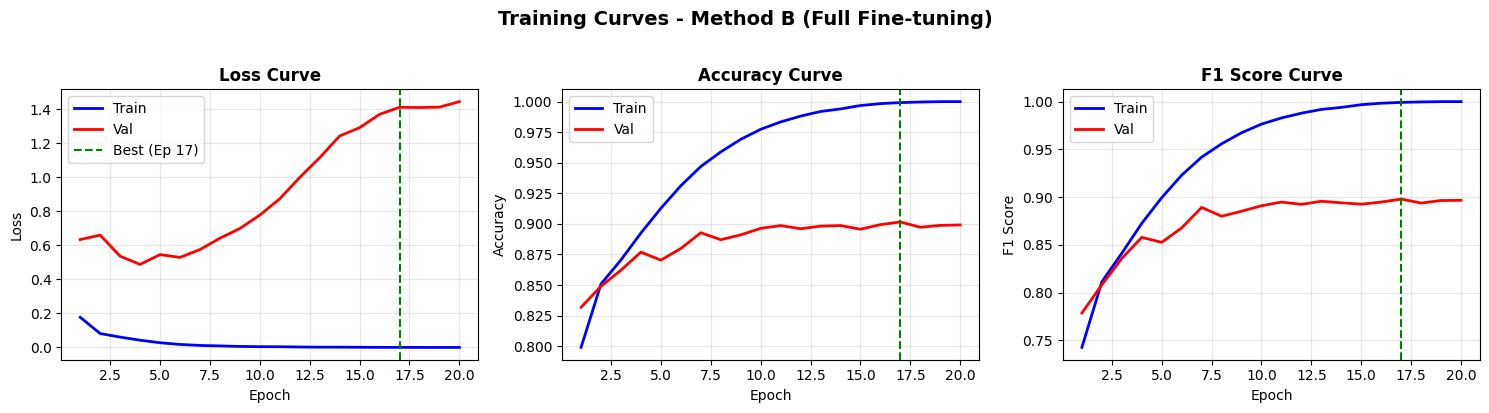

✅ Saved: training_curves.png


In [11]:
# === TRAINING CURVES ===
fig, ax = plt.subplots(1, 3, figsize=(15,4))
ep_range = range(1, len(history['train_loss'])+1)

ax[0].plot(ep_range, history['train_loss'], 'b-', label='Train', linewidth=2)
ax[0].plot(ep_range, history['val_loss'], 'r-', label='Val', linewidth=2)
ax[0].axvline(best_epoch, color='g', ls='--', label=f'Best (Ep {best_epoch})')
ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('Loss'); ax[0].set_title('Loss Curve', fontweight='bold')
ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(ep_range, history['train_acc'], 'b-', label='Train', linewidth=2)
ax[1].plot(ep_range, history['val_acc'], 'r-', label='Val', linewidth=2)
ax[1].axvline(best_epoch, color='g', ls='--')
ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('Accuracy'); ax[1].set_title('Accuracy Curve', fontweight='bold')
ax[1].legend(); ax[1].grid(alpha=0.3)

ax[2].plot(ep_range, history['train_f1'], 'b-', label='Train', linewidth=2)
ax[2].plot(ep_range, history['val_f1'], 'r-', label='Val', linewidth=2)
ax[2].axvline(best_epoch, color='g', ls='--')
ax[2].set_xlabel('Epoch'); ax[2].set_ylabel('F1 Score'); ax[2].set_title('F1 Score Curve', fontweight='bold')
ax[2].legend(); ax[2].grid(alpha=0.3)

plt.suptitle('Training Curves - Method B (Full Fine-tuning)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: training_curves.png")

## 12. Load Best Model & Evaluate on Test Set

In [12]:
# === LOAD BEST MODEL ===
checkpoint = torch.load(os.path.join(OUTPUT_DIR, 'best_model.pth'))
model.load_state_dict(checkpoint['model_state_dict'])
print(f"✅ Loaded best model from epoch {checkpoint['epoch']+1}, Val F1: {checkpoint['val_f1']:.4f}")

✅ Loaded best model from epoch 17, Val F1: 0.8979


In [13]:
# === FINAL EVALUATION ===
print("📊 Evaluating on TEST SET...")
te_l, te_a, te_f, y_true, y_pred, y_probs = evaluate(model, test_loader, criterion, device)

prec_w = precision_score(y_true, y_pred, average='weighted')
rec_w = recall_score(y_true, y_pred, average='weighted')
f1_m = f1_score(y_true, y_pred, average='macro')
prec_c = precision_score(y_true, y_pred, average=None)
rec_c = recall_score(y_true, y_pred, average=None)
f1_c = f1_score(y_true, y_pred, average=None)

print(f"\n{'='*50}")
print(f"🎯 TEST SET RESULTS")
print(f"{'='*50}")
print(f"   Accuracy:    {te_a:.4f} ({te_a*100:.2f}%)")
print(f"   F1 Weighted: {te_f:.4f}")
print(f"   F1 Macro:    {f1_m:.4f}")
print(f"   Precision:   {prec_w:.4f}")
print(f"   Recall:      {rec_w:.4f}")

📊 Evaluating on TEST SET...



🎯 TEST SET RESULTS
   Accuracy:    0.8980 (89.80%)
   F1 Weighted: 0.8928
   F1 Macro:    0.6371
   Precision:   0.8898
   Recall:      0.8980


In [14]:
# === PER-CLASS METRICS ===
print(f"\n📊 Per-Class Metrics:")
mdf = pd.DataFrame({'Class': TARGET_CLASSES, 'Precision': prec_c, 'Recall': rec_c, 'F1': f1_c, 'Support': [sum(y_true==i) for i in range(NUM_CLASSES)]}).round(4)
print(mdf.to_string(index=False))
mdf.to_csv(os.path.join(OUTPUT_DIR, 'per_class_metrics.csv'), index=False)
print("\n✅ Saved: per_class_metrics.csv")

print(f"\n📊 Classification Report:")
report = classification_report(y_true, y_pred, target_names=TARGET_CLASSES, digits=4)
print(report)
with open(os.path.join(OUTPUT_DIR, 'classification_report.txt'), 'w') as f: f.write(report)
print("✅ Saved: classification_report.txt")


📊 Per-Class Metrics:
Class  Precision  Recall     F1  Support
 NORM     0.9525  0.9772 0.9647    18880
  AMI     0.2584  0.1278 0.1710      360
 ASMI     0.7823  0.8211 0.8012     3360
 ILMI     0.6555  0.4522 0.5352      690
  IMI     0.7468  0.6825 0.7132     3030

✅ Saved: per_class_metrics.csv

📊 Classification Report:
              precision    recall  f1-score   support

        NORM     0.9525    0.9772    0.9647     18880
         AMI     0.2584    0.1278    0.1710       360
        ASMI     0.7823    0.8211    0.8012      3360
        ILMI     0.6555    0.4522    0.5352       690
         IMI     0.7468    0.6825    0.7132      3030

    accuracy                         0.8980     26320
   macro avg     0.6791    0.6122    0.6371     26320
weighted avg     0.8898    0.8980    0.8928     26320

✅ Saved: classification_report.txt


## 13. Confusion Matrix

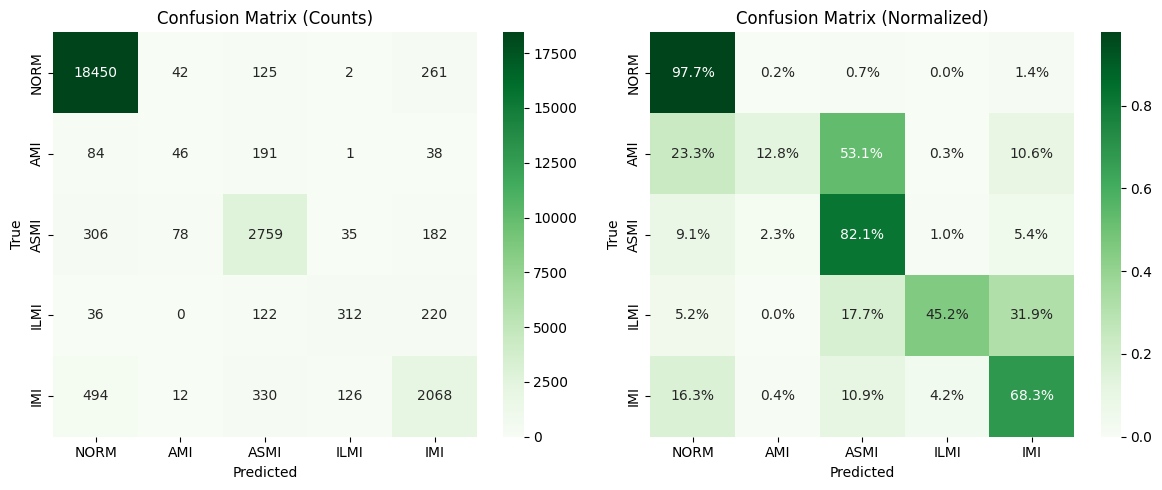

✅ Saved: confusion_matrix.png


In [15]:
# === CONFUSION MATRIX ===
cm = confusion_matrix(y_true, y_pred)
cm_n = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES, ax=ax[0])
ax[0].set_xlabel('Predicted'); ax[0].set_ylabel('True'); ax[0].set_title('Confusion Matrix (Counts)')
sns.heatmap(cm_n, annot=True, fmt='.1%', cmap='Greens', xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES, ax=ax[1])
ax[1].set_xlabel('Predicted'); ax[1].set_ylabel('True'); ax[1].set_title('Confusion Matrix (Normalized)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()
print("✅ Saved: confusion_matrix.png")

## 14. ROC Curves

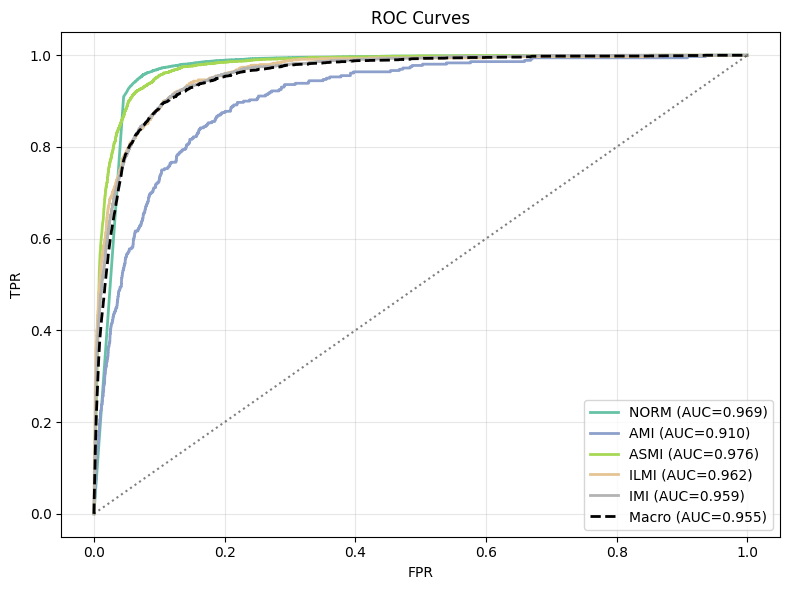


📊 AUC Scores:
   NORM: 0.9690
   AMI: 0.9096
   ASMI: 0.9762
   ILMI: 0.9616
   IMI: 0.9593
   Macro: 0.9552

✅ Saved: roc_curves.png


In [16]:
# === ROC CURVES ===
y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.Set2(np.linspace(0, 1, NUM_CLASSES))
aucs = []

for i, (c, col) in enumerate(zip(TARGET_CLASSES, colors)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_probs[:, i])
    a = auc(fpr, tpr); aucs.append(a)
    ax.plot(fpr, tpr, color=col, lw=2, label=f'{c} (AUC={a:.3f})')

all_fpr = np.unique(np.concatenate([roc_curve(y_bin[:,i], y_probs[:,i])[0] for i in range(NUM_CLASSES)]))
mean_tpr = np.mean([np.interp(all_fpr, *roc_curve(y_bin[:,i], y_probs[:,i])[:2]) for i in range(NUM_CLASSES)], axis=0)
macro_auc = auc(all_fpr, mean_tpr)
ax.plot(all_fpr, mean_tpr, 'k--', lw=2, label=f'Macro (AUC={macro_auc:.3f})')
ax.plot([0,1], [0,1], 'k:', alpha=0.5)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title('ROC Curves'); ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'roc_curves.png'), dpi=150)
plt.show()

print(f"\n📊 AUC Scores:")
for c, a in zip(TARGET_CLASSES, aucs): print(f"   {c}: {a:.4f}")
print(f"   Macro: {macro_auc:.4f}")
print("\n✅ Saved: roc_curves.png")

## 15. Save All Results

In [17]:
# === SAVE RESULTS ===
results = {
    'method': 'B - Full ViT Fine-tuning',
    'model': MODEL_NAME,
    'params': total_params,
    'dataset': {
        'train': len(train_df),
        'val': len(val_df),
        'test': len(test_df)
    },
    'hyperparams': {
        'batch_size': BATCH_SIZE,
        'epochs_trained': len(history['train_loss']),
        'best_epoch': best_epoch,
        'lr_backbone': LR_BACKBONE,
        'lr_head': LR_HEAD,
        'weight_decay': WEIGHT_DECAY,
        'warmup_epochs': WARMUP_EPOCHS
    },
    'test_results': {
        'accuracy': float(te_a),
        'f1_weighted': float(te_f),
        'f1_macro': float(f1_m),
        'precision': float(prec_w),
        'recall': float(rec_w),
        'macro_auc': float(macro_auc)
    },
    'per_class': {
        'f1': dict(zip(TARGET_CLASSES, [float(f) for f in f1_c])),
        'auc': dict(zip(TARGET_CLASSES, [float(a) for a in aucs]))
    },
    'training_time': str(train_time)
}

with open(os.path.join(OUTPUT_DIR, 'results.json'), 'w') as f:
    json.dump(results, f, indent=2)
print("✅ Saved: results.json")

# Save training history
pd.DataFrame(history).to_csv(os.path.join(OUTPUT_DIR, 'history.csv'), index=False)
print("✅ Saved: history.csv")

print(f"\n{'='*50}")
print(f"📁 ALL FILES SAVED TO: {OUTPUT_DIR}")
print(f"{'='*50}")
for f in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(os.path.join(OUTPUT_DIR, f)) / 1024
    print(f"   • {f} ({size:.1f} KB)")

✅ Saved: results.json
✅ Saved: history.csv

📁 ALL FILES SAVED TO: /workspace/output_method_b
   • best_model.pth (335244.9 KB)
   • classification_report.txt (0.5 KB)
   • confusion_matrix.png (106.3 KB)
   • history.csv (2.7 KB)
   • per_class_metrics.csv (0.2 KB)
   • results.json (1.0 KB)
   • roc_curves.png (97.5 KB)
   • training_curves.png (109.6 KB)


## 16. Final Summary

In [18]:
# === FINAL SUMMARY ===
print(f"\n{'='*60}")
print(f"🎉 METODE B COMPLETE!")
print(f"{'='*60}")
print(f"\n📋 Model: {MODEL_NAME} ({total_params:,} params)")
print(f"📊 Data: Train {len(train_df):,} | Val {len(val_df):,} | Test {len(test_df):,}")
print(f"\n🎯 TEST RESULTS:")
print(f"   Accuracy:    {te_a*100:.2f}%")
print(f"   F1 Weighted: {te_f:.4f}")
print(f"   F1 Macro:    {f1_m:.4f}")
print(f"   Macro AUC:   {macro_auc:.4f}")
print(f"\n📈 Per-Class F1:")
for c, f in zip(TARGET_CLASSES, f1_c): print(f"   {c:6s}: {f:.4f} {'█'*int(f*30)}")
print(f"\n⏱️ Training Time: {train_time}")
print(f"📁 Output: {OUTPUT_DIR}")
print("="*60)


🎉 METODE B COMPLETE!

📋 Model: google/vit-base-patch16-224 (85,802,501 params)
📊 Data: Train 92,100 | Val 13,160 | Test 26,320

🎯 TEST RESULTS:
   Accuracy:    89.80%
   F1 Weighted: 0.8928
   F1 Macro:    0.6371
   Macro AUC:   0.9552

📈 Per-Class F1:
   NORM  : 0.9647 ████████████████████████████
   AMI   : 0.1710 █████
   ASMI  : 0.8012 ████████████████████████
   ILMI  : 0.5352 ████████████████
   IMI   : 0.7132 █████████████████████

⏱️ Training Time: 1:41:59.332866
📁 Output: /workspace/output_method_b
